# House prices — EDA

One small experiment a day. Seed fixed for reproducibility.

No modeling today. Distributions, price vs sqft, neighborhood effects.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              HistGradientBoostingClassifier, VotingClassifier,
                              IsolationForest)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, mean_squared_error,
                             mean_absolute_error, r2_score, silhouette_score)


## Data

In [ ]:
SEED = 1248

rng = np.random.RandomState(SEED)
n = 3000
sqft = rng.uniform(500, 4000, n).round(0)
bedrooms = rng.choice([1, 2, 3, 4, 5], size=n, p=[0.10, 0.30, 0.35, 0.20, 0.05])
bathrooms = np.clip(bedrooms - rng.choice([0, 1], size=n, p=[0.6, 0.4]), 1, 5)
age_yrs = rng.uniform(0, 60, n).round(1)
neighborhood = rng.choice(["A", "B", "C", "D"], size=n, p=[0.25, 0.35, 0.25, 0.15])
hood_eff = {"A": 42000, "B": 16000, "C": 0, "D": -22000}
price = (80000 + 118 * sqft + 14500 * bedrooms - 850 * age_yrs
         + np.array([hood_eff[x] for x in neighborhood])
         + rng.normal(0, 28000, n))
df = pd.DataFrame({"Sqft": sqft, "Bedrooms": bedrooms, "Bathrooms": bathrooms,
                   "Age": age_yrs, "Neighborhood": neighborhood,
                   "Price": price.round(0).astype(int)})
print("shape:", df.shape)
print(df.head(3).to_string())
print("\nmedian price: %d" % int(df["Price"].median()))


shape: (3000, 6)
     Sqft  Bedrooms  Bathrooms   Age Neighborhood   Price
0  1537.0         1          1  42.9            C  223124
1  2254.0         2          1  34.4            A  421945
2  2526.0         3          2  59.7            A  427957

median price: 368431


## Price distribution

count      3000.0
mean     371473.0
std      127825.0
min       75978.0
25%      268144.0
50%      368431.0
75%      476934.0
max      670745.0


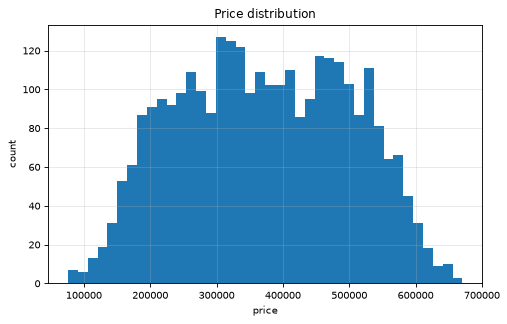

In [ ]:

fig, ax = plt.subplots()
ax.hist(df["Price"], bins=40)
ax.set_xlabel("price"); ax.set_ylabel("count"); ax.set_title("Price distribution")
print(df["Price"].describe().round(0).to_string())


## Price vs sqft by neighborhood

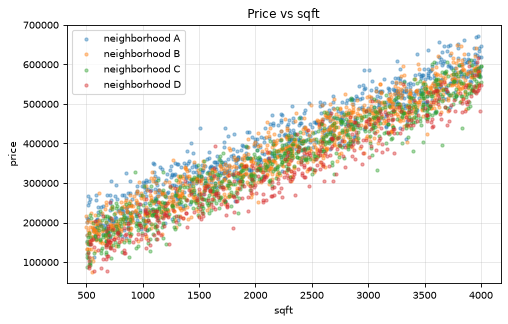

In [ ]:

fig, ax = plt.subplots()
for nb, d in df.groupby("Neighborhood"):
    ax.scatter(d["Sqft"], d["Price"], s=8, alpha=0.4, label=f"neighborhood {nb}")
ax.set_xlabel("sqft"); ax.set_ylabel("price"); ax.legend(); ax.set_title("Price vs sqft")


## Correlations

In [ ]:

print(df[["Sqft", "Bedrooms", "Bathrooms", "Age", "Price"]].corr().round(2).to_string())


           Sqft  Bedrooms  Bathrooms   Age  Price
Sqft       1.00     -0.01      -0.01  0.01   0.95
Bedrooms  -0.01      1.00       0.90  0.02   0.10
Bathrooms -0.01      0.90       1.00  0.01   0.09
Age        0.01      0.02       0.01  1.00  -0.10
Price      0.95      0.10       0.09 -0.10   1.00


## Takeaways

- Sqft is the dominant driver; neighborhood shifts the intercept.
- Bedrooms/bathrooms are collinear — keep one or regularize.